# Functional Model

In [1]:
import tensorflow
from tensorflow import keras
from keras.utils import plot_model
from keras.layers import *
from keras.models import Model
import pydot

### Multiple Outputs

In [2]:
x = Input(batch_size=32, shape=(3,),)

hidden1 = Dense(128, activation='relu')(x)
hidden2 = Dense(64, activation='relu')(hidden1)

output1 = Dense(1, activation='linear')(hidden2)
output2 = Dense(1, activation='sigmoid')(hidden2)

In [3]:
model = Model(inputs = x, outputs = [output1, output2])

In [4]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape             ┃          Param # ┃ Connected to              ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (32, 3)                  │                0 │ -                         │
├───────────────────────────────┼──────────────────────────┼──────────────────┼───────────────────────────┤
│ dense (Dense)                 │ (32, 128)                │              512 │ input_layer[0][0]         │
├───────────────────────────────┼──────────────────────────┼──────────────────┼───────────────────────────┤
│ dense_1 (Dense)               │ (32, 64)                 │            8,256 │ dense[0][0]               │
├───────────────────────────────┼──────────────────────────┼──────────────────┼───────────────────────────┤
│ dense_2 (Dense)               │ (32, 1)                  │               65 │ dense_1[0][0]             │
├───────────────────────────────┼──────────────────────────┼──────────────────┼───────────────────────────┤
│ dense_3 (Dense)               │ (32, 1)                  │               65 │ dense_1[0][0]             │
└───────────────────────────────┴──────────────────────────┴──────────────────┴───────────────────────────┘

 Total params: 8,898 (34.76 KB)

 Trainable params: 8,898 (34.76 KB)

 Non-trainable params: 0 (0.00 B)

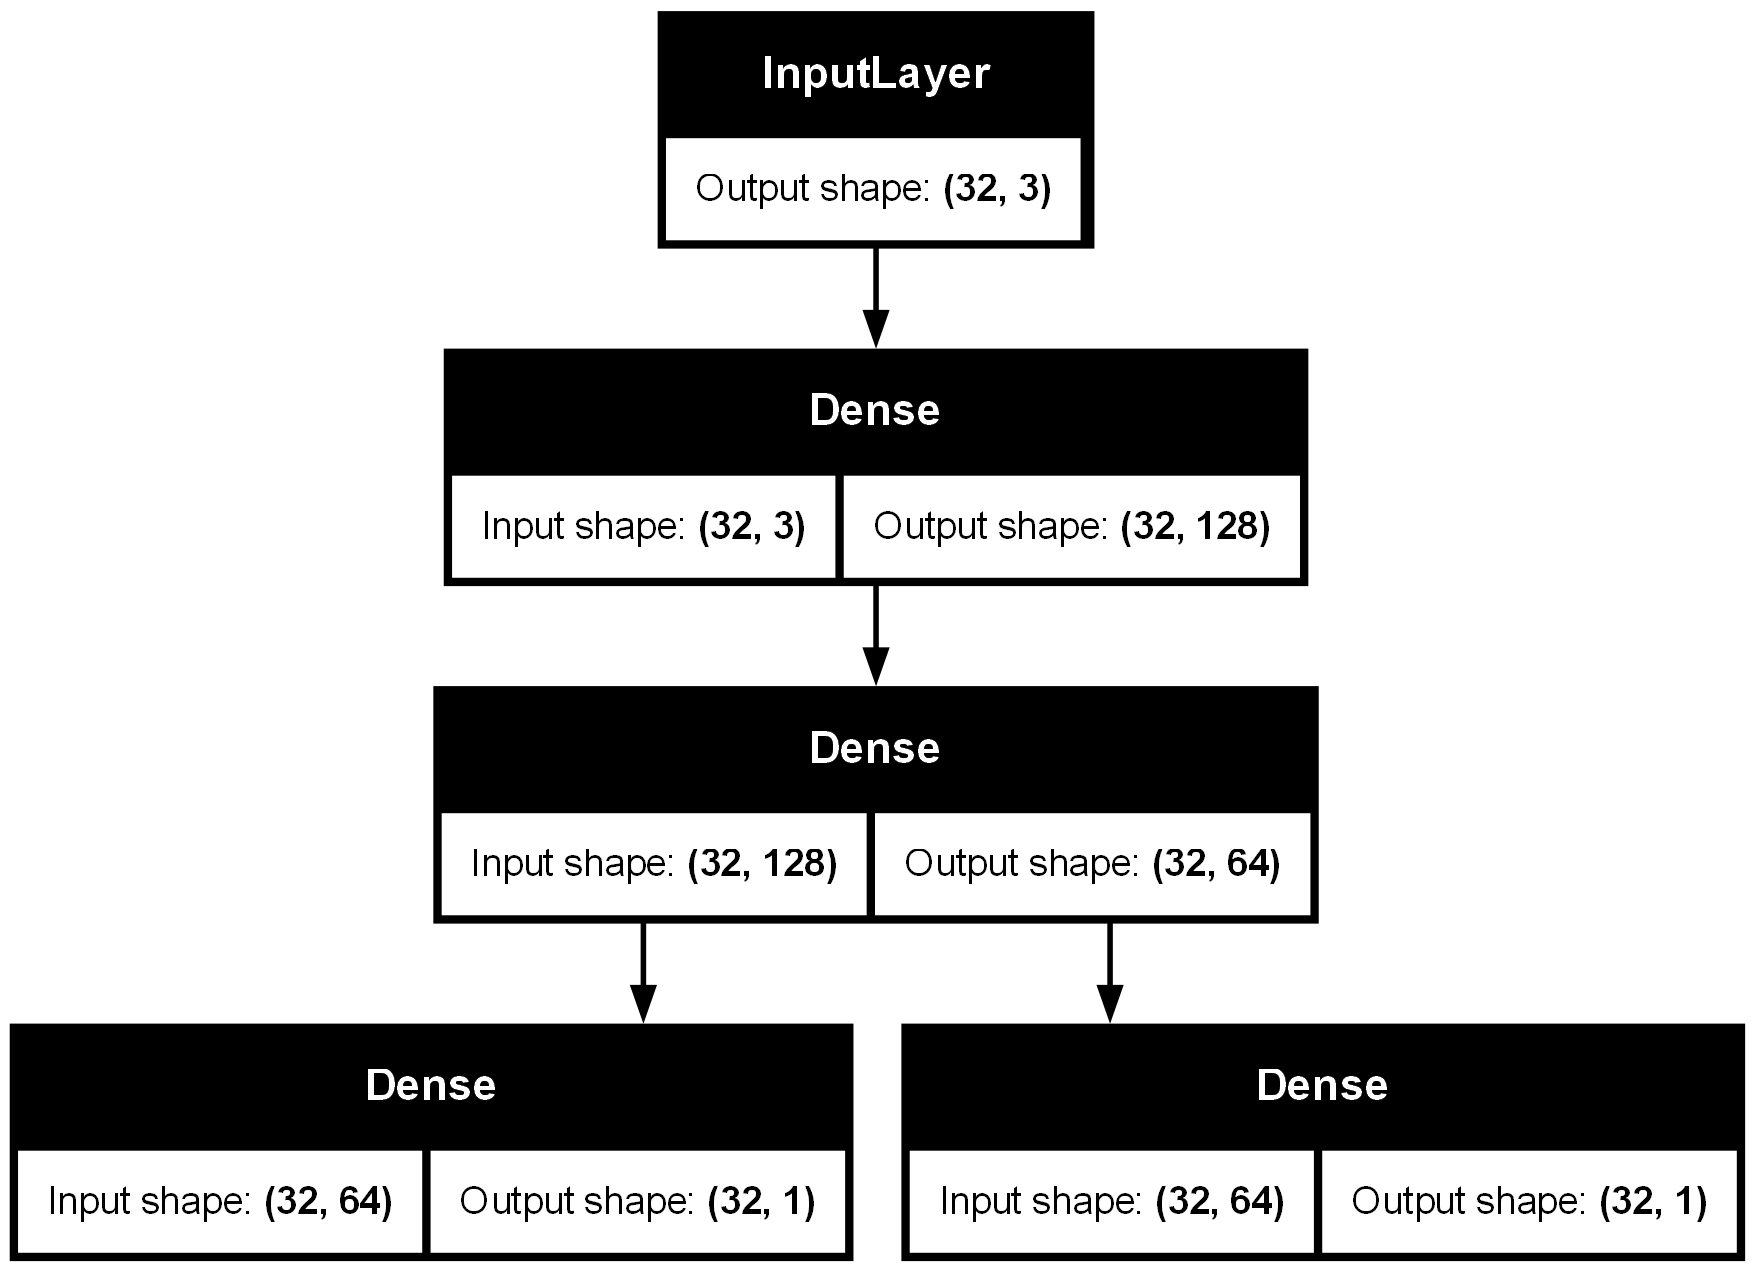

In [8]:
plot_model(model, show_shapes=True)

### Multiple Inputs

In [11]:
A = Input(shape=(3,))
B = Input(shape=(2,))

hiddenA1 = Dense(128, activation='relu')(A)
hiddenA2 = Dense(64, activation='relu')(hiddenA1)

hiddenB1 = Dense(32, activation='tanh')(B)

combine = concatenate([hiddenA2, hiddenB1])

fully_connected1 = Dense(24, activation='relu')(combine)
output = Dense(1, activation='sigmoid')(fully_connected1)

In [12]:
model = Model(inputs=[A, B], outputs=[output])

In [13]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape             ┃          Param # ┃ Connected to              ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)    │ (None, 3)                │                0 │ -                         │
├───────────────────────────────┼──────────────────────────┼──────────────────┼───────────────────────────┤
│ dense_9 (Dense)               │ (None, 128)              │              512 │ input_layer_3[0][0]       │
├───────────────────────────────┼──────────────────────────┼──────────────────┼───────────────────────────┤
│ input_layer_4 (InputLayer)    │ (None, 2)                │                0 │ -                         │
├───────────────────────────────┼──────────────────────────┼──────────────────┼───────────────────────────┤
│ dense_10 (Dense)              │ (None, 64)               │            8,256 │ dense_9[0][0]             │
├───────────────────────────────┼──────────────────────────┼──────────────────┼───────────────────────────┤
│ dense_11 (Dense)              │ (None, 32)               │               96 │ input_layer_4[0][0]       │
├───────────────────────────────┼──────────────────────────┼──────────────────┼───────────────────────────┤
│ concatenate_1 (Concatenate)   │ (None, 96)               │                0 │ dense_10[0][0],           │
│                               │                          │                  │ dense_11[0][0]            │
├───────────────────────────────┼──────────────────────────┼──────────────────┼───────────────────────────┤
│ dense_12 (Dense)              │ (None, 24)               │            2,328 │ concatenate_1[0][0]       │
├───────────────────────────────┼──────────────────────────┼──────────────────┼───────────────────────────┤
│ dense_13 (Dense)              │ (None, 1)                │               25 │ dense_12[0][0]            │
└───────────────────────────────┴──────────────────────────┴──────────────────┴───────────────────────────┘

 Total params: 11,217 (43.82 KB)

 Trainable params: 11,217 (43.82 KB)

 Non-trainable params: 0 (0.00 B)

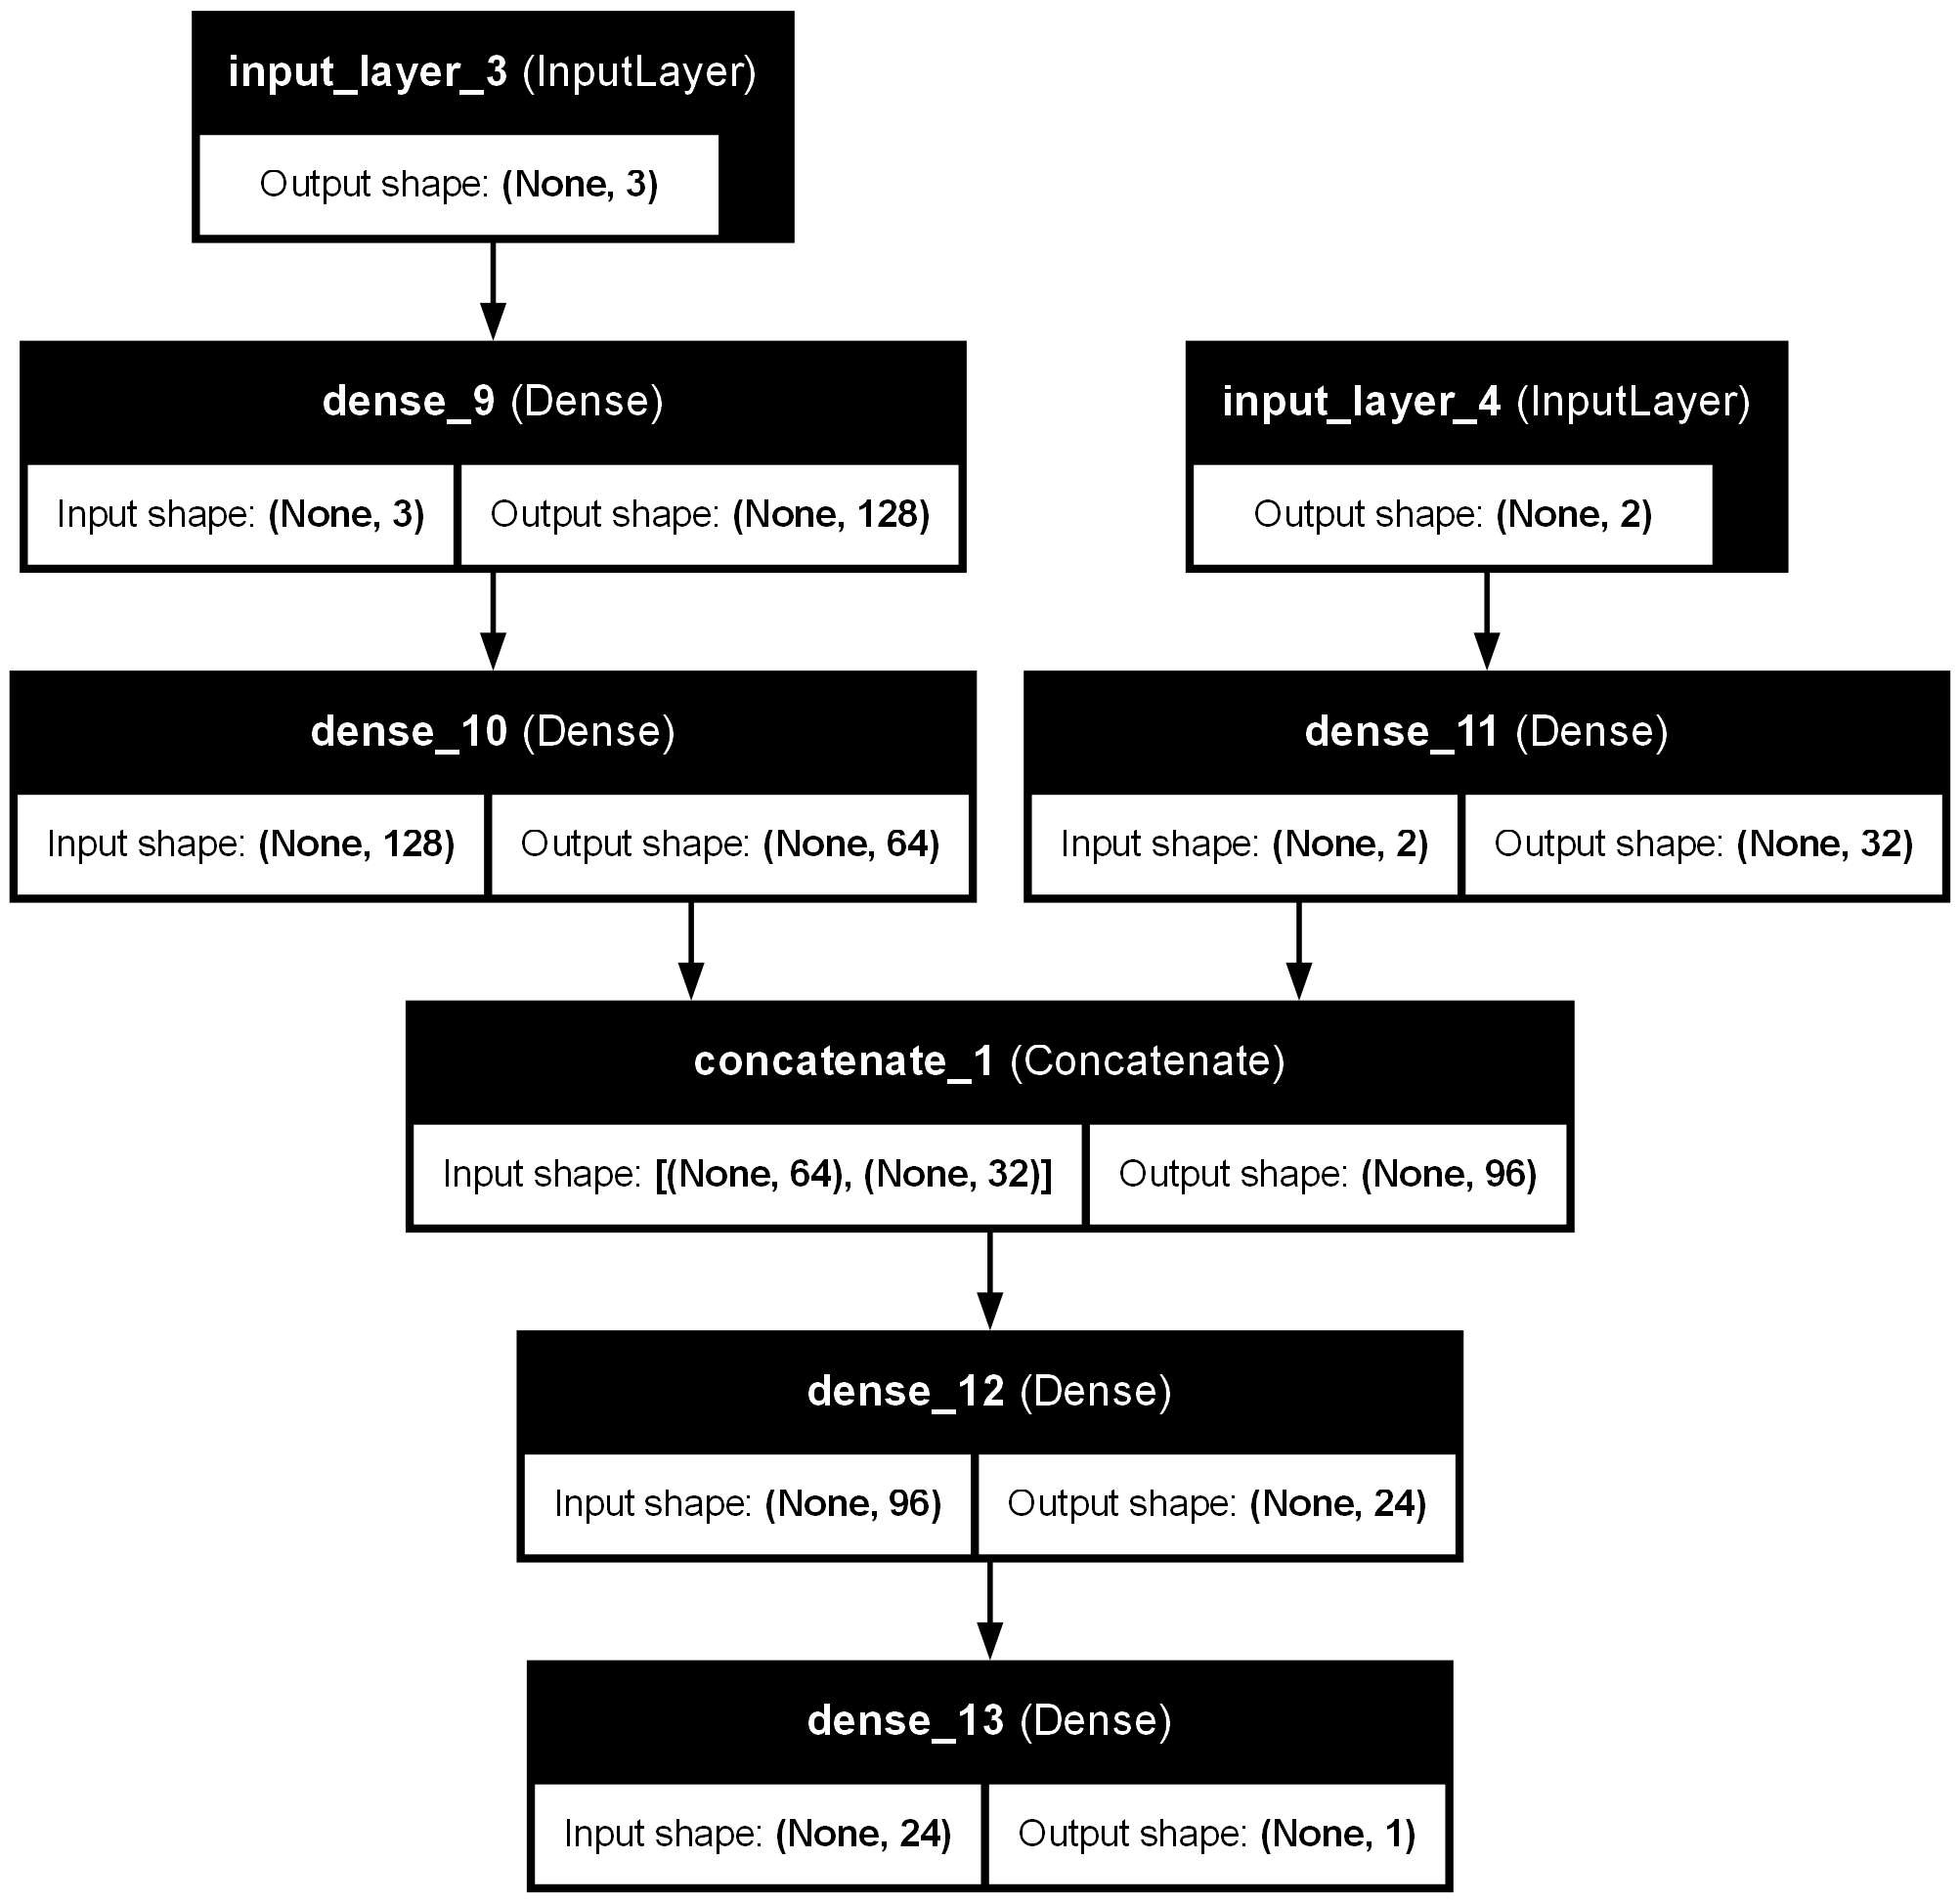

In [15]:
plot_model(model, show_layer_names=True, show_shapes=True)